In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from PIL import Image # Import Pillow

C:\Users\LOQ\AppData\Local\Programs\Python\Python313\Lib\site-packages\tensorflow\python\keras\engine\training_arrays_v1.py:37: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.4.3)
  from scipy.sparse import issparse  # pylint: disable=g-import-not-at-top


Task 1: Data Understanding and Visualization:

Training set: (90, 256, 256, 3), Labels: (90, 10)
Testing set: (30, 256, 256, 3), Labels: (30, 10)


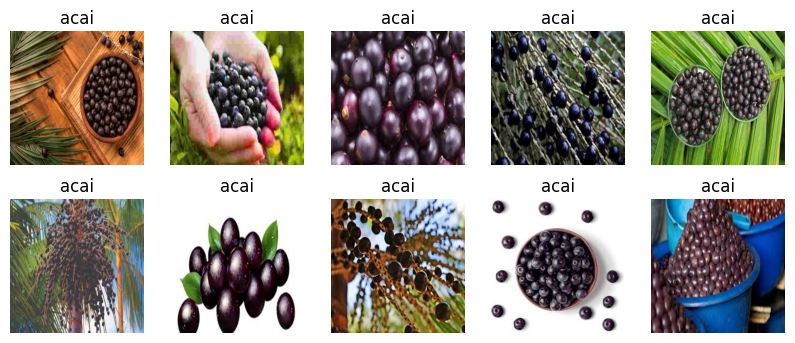

In [2]:
# Define dataset paths
train_dir = "FruitinAmazon/FruitinAmazon/train/"
test_dir = "FruitinAmazon/FruitinAmazon/test/"
# Define image size
img_height, img_width = 256, 256
# Function to load images and labels using PIL
def load_images_from_folder(folder):
    images = []
    labels = []
    class_names = sorted(os.listdir(folder)) # Sorted class names
    class_map = {name: i for i, name in enumerate(class_names)} # Map class names to labels
    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        label = class_map[class_name]
        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)
            # Load image using PIL
            img = Image.open(img_path) # Removed .convert("L") to keep as RGB
            img = img.resize((img_width, img_height)) # Resize to (28,28)
            img = np.array(img) / 255.0 # Normalize pixel values to [0,1]
            images.append(img)
            labels.append(label)
    return np.array(images), np.array(labels), np.array(class_names)
# Load training and testing datasets
x_train, y_train, class_names_train = load_images_from_folder(train_dir)
x_test, y_test, class_names_test = load_images_from_folder(test_dir)
# Reshape images for Keras input
x_train = x_train.reshape(-1, img_height, img_width, 3) # Shape (num_samples, 28, 28, 3) for RGB
x_test = x_test.reshape(-1, img_height, img_width, 3)
# One-hot encode labels
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)
# Print dataset shape
print(f"Training set: {x_train.shape}, Labels: {y_train.shape}")
print(f"Testing set: {x_test.shape}, Labels: {y_test.shape}")
# Visualize some images
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i]) # Removed reshape(1000, 1000) for RGB image
    label_index = np.argmax(y_train[i])
    plt.title(f"{class_names_train[label_index]}")
    plt.axis("off")
plt.show()

In [3]:
from logging import exception
def find_corrupt_images(folder):
  image_removed = False
  class_names = sorted(os.listdir(folder)) # Sorted class names
  class_map = {name: i for i, name in enumerate(class_names)} # Map class names to labels
  for class_name in class_names:
      class_path = os.path.join(folder, class_name)
      label = class_map[class_name]
      for filename in os.listdir(class_path):
          img_path = os.path.join(class_path, filename)
          # Load image using PIL
          try:
            img = Image.open(img_path)
            img.verify()
          except Exception:
            image_removed = True
            print(f"Corrupt image found: {img_path}")
            os.remove(img_path)
  return image_removed

if find_corrupt_images(train_dir):
  print("corrupt images found and removed")
else:
  print("no corrupt images found")

no corrupt images found


Task 2: Loading and Preprocessing Image Data in keras:

In [4]:
batch_size = 16
validation_split = 0.2

# Create a preprocessing layer for normalization
rescale = tf.keras.layers.Rescaling(1./255) # Normalize pixel values to [0, 1]

In [5]:
# Create training dataset with normalization
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir, labels='inferred', label_mode='int', image_size=(img_height, img_width),
    interpolation='nearest', batch_size=batch_size, shuffle=True,
    validation_split=validation_split, subset='training',
    seed=1234
)
#get names before normolizaa
class_names_train = train_ds.class_names
num_classes = len(class_names_train)

# Apply the normalization (Rescaling) to the dataset
train_ds = train_ds.map(lambda x, y: (rescale(x), y))

# Create validation dataset with normalization
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)
# Apply the normalization (Rescaling) to the validation dataset
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

print(f"Number of training batches: {tf.data.experimental.cardinality(train_ds)}")
print(f"Number of validation batches: {tf.data.experimental.cardinality(val_ds)}")

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Number of training batches: 5
Number of validation batches: 2


Task 3 - Implement a CNN with:

In [6]:
# Define the CNN model architecture
model = tf.keras.models.Sequential([
    # Convolutional Layer 1
    tf.keras.layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(img_height, img_width, 3)),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Convolutional Layer 2
    tf.keras.layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Flatten Layer
    tf.keras.layers.Flatten(),

    # Fully Connected Network
    tf.keras.layers.Dense(128, activation='relu'), # Hidden Layer - 2 (128 neurons)
    tf.keras.layers.Dense(64, activation='relu'),  # Hidden Layer - 1 (64 neurons, as per typical FC order where 2 is larger)

    # Output Layer
    tf.keras.layers.Dense(10, activation='softmax') # num_classes for classification
])

model.summary()

C:\Users\LOQ\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 256, 256, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 128, 128, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 128, 128, 32)        │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 131072)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │      16,777,344 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 16,796,394 (64.07 MB)

 Trainable params: 16,796,394 (64.07 MB)

 Non-trainable params: 0 (0.00 B)

Task 4: Compile and Train the Model

In [7]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks for training
callbacks = [
    tf.keras.callbacks.ModelCheckpoint('best_model.h5', save_best_only=True, monitor='val_accuracy', mode='max'),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
]

# Train the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    callbacks=callbacks
)

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 691ms/step - accuracy: 0.1382 - loss: 2.9766

5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.1389 - loss: 3.6493 - val_accuracy: 0.1667 - val_loss: 2.2375
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 798ms/step - accuracy: 0.1806 - loss: 2.2259 - val_accuracy: 0.0556 - val_loss: 2.4644
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 644ms/step - accuracy: 0.4750 - loss: 1.6685

5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 980ms/step - accuracy: 0.4583 - loss: 1.6921 - val_accuracy: 0.6111 - val_loss: 1.3626
Epoch 4/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 774ms/step - accuracy: 0.5972 - loss: 1.2606 - val_accuracy: 0.5556 - val_loss: 1.1596
Epoch 5/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 799ms/step - accuracy: 0.7917 - loss: 0.7309 - val_accuracy: 0.6111 - val_loss: 0.9349
Epoch 6/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 681ms/step - accuracy: 0.9201 - loss: 0.3685

5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.9028 - loss: 0.4031 - val_accuracy: 0.8889 - val_loss: 0.3222
Epoch 7/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 780ms/step - accuracy: 0.8750 - loss: 0.2878 - val_accuracy: 0.7222 - val_loss: 0.6871
Epoch 8/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 774ms/step - accuracy: 1.0000 - loss: 0.1118 - val_accuracy: 0.7778 - val_loss: 0.6413
Epoch 9/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 782ms/step - accuracy: 1.0000 - loss: 0.0501 - val_accuracy: 0.8333 - val_loss: 0.3156
Epoch 10/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 787ms/step - accuracy: 1.0000 - loss: 0.0244 - val_accuracy: 0.8333 - val_loss: 0.5132
Epoch 11/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 775ms/step - accuracy: 1.0000 - loss: 0.0139 - val_accuracy: 0.8333 - val_loss: 0.6043
Epoch 12/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 786ms/step - accuracy: 1.0000 - loss: 0.0057 - val_accuracy: 0.8333 - val_loss: 0.6204
Epoch 13/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 799ms/step - accuracy: 1.0000 - loss: 0.0031 - val_accuracy: 0.8333 - val_loss: 0.

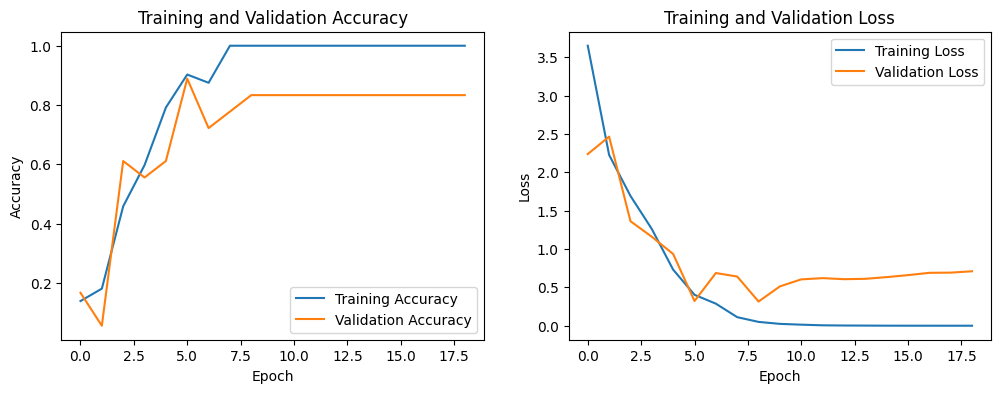

In [8]:
# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [12]:
print(y_test.shape)
print(best_model.output_shape)

(30,)


NameError: name 'best_model' is not defined

In [10]:
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

print("Unique labels in y_test:", np.unique(y_test))

x_test shape: (30, 256, 256, 3)
y_test shape: (30, 10)
Unique labels in y_test: [0. 1.]


Task 5: Evaluate the Model

In [11]:
# Load the best model saved by ModelCheckpoint
loaded_model = tf.keras.models.load_model('best_model.h5')
y_test = np.argmax(y_test, axis=1)
# Evaluate the model on the test set
loss, accuracy = loaded_model.evaluate(x_test, y_test)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.6667 - loss: 0.8546
Test Loss: 0.8546
Test Accuracy: 0.6667


Task 6: Save and Load the Model

In [15]:
# Save the model efficiently
model.save('final_fruit_classifier_model.h5', save_format='h5')

loaded_model_reloaded = tf.keras.models.load_model('final_fruit_classifier_model.h5')
print("Model reloaded successfully.")

Model reloaded successfully.


Task 7: Predictions and Classification Report

In [16]:
from sklearn.metrics import classification_report

# Make predictions on test images
predictions = loaded_model.predict(x_test)

# Convert predicted probabilities to digit labels
predicted_labels = np.argmax(predictions, axis=1)

if y_test.ndim == 1:
    true_labels = y_test  # Already integers
else:
    true_labels = np.argmax(y_test, axis=1)  # Convert one-hot to integers

# Now generate classification report
print("Classification Report:")
print(classification_report(true_labels, predicted_labels))
# Generate and print the classification report
print("Classification Report:")
print(classification_report(true_labels, predicted_labels, target_names=class_names_test))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 627ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.60      0.67         5
           1       0.44      0.80      0.57         5
           2       1.00      0.80      0.89         5
           3       1.00      0.40      0.57         5
           4       0.62      1.00      0.77         5
           5       0.67      0.40      0.50         5

    accuracy                           0.67        30
   macro avg       0.75      0.67      0.66        30
weighted avg       0.75      0.67      0.66        30

Classification Report:
              precision    recall  f1-score   support

        acai       0.75      0.60      0.67         5
     cupuacu       0.44      0.80      0.57         5
    graviola       1.00      0.80      0.89         5
     guarana       1.00      0.40      0.57         5
     pupunha       0.62      1.00      0.77         5
      tucuma       0.67      0.40      0.50    